In [2]:
import sqlite3
import pandas as pd


In [3]:
conn=sqlite3.connect("/home/adi/Documents/project/data/inventory.db")

In [4]:
tables=pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",conn)

In [5]:
for table in tables['name']:
    print(table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
purchase_aggr_df=pd.read_sql_query("""select
PONumber,
count(DISTINCT Brand) as Total_Brand,
sum(Quantity) as Total_Quantity,
sum(Dollars) Total_Dollars,
avg(julianday(ReceivingDate)-julianday(PODate)) as avg_reaciving_delay 
from purchases
group by PONumber""",conn)

In [7]:
purchase_aggr_df.head()

,PONumber,Total_Brand,Total_Quantity,Total_Dollars,avg_reaciving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [8]:
pd.read_sql_query("""
select 
PONumber,
Quantity,
Dollars,
Freight,
julianday(InvoiceDate)-julianday(PODate) as day_po_to_invoice,
julianday(PayDate)-julianday(InvoiceDate) as days_to_pay
from vendor_invoice""",conn)

,PONumber,Quantity,Dollars,Freight,day_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [9]:
df = pd.read_sql_query("""
WITH purchase_aggr AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS Total_Brands,
        SUM(p.Quantity) AS Total_Item_Quantity,
        SUM(p.Dollars) AS Total_Item_Dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS Avg_Receiving_Delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS Invoice_Quantity,
    vi.Dollars AS Invoice_Dollars,
    vi.Freight,

    julianday(vi.InvoiceDate) - julianday(vi.PODate) AS Days_PO_To_Invoice,

    julianday(vi.PayDate) - julianday(vi.InvoiceDate) AS Days_To_Pay,

    pa.Total_Brands,
    pa.Total_Item_Quantity,
    pa.Total_Item_Dollars,
    pa.Avg_Receiving_Delay

FROM vendor_invoice vi

LEFT JOIN purchase_aggr pa
ON vi.PONumber = pa.PONumber
""", conn)

In [10]:
df.head()

,PONumber,Invoice_Quantity,Invoice_Dollars,Freight,Days_PO_To_Invoice,Days_To_Pay,Total_Brands,Total_Item_Quantity,Total_Item_Dollars,Avg_Receiving_Delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


<Axes: >

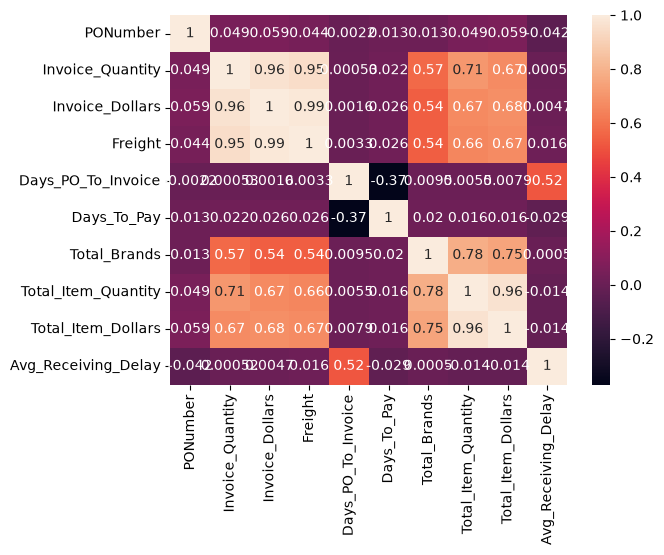

In [11]:
import seaborn as sns
sns.heatmap(df.corr(),annot=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   Invoice_Quantity     5543 non-null   int64  
 2   Invoice_Dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   Days_PO_To_Invoice   5543 non-null   float64
 5   Days_To_Pay          5543 non-null   float64
 6   Total_Brands         5543 non-null   int64  
 7   Total_Item_Quantity  5543 non-null   int64  
 8   Total_Item_Dollars   5543 non-null   float64
 9   Avg_Receiving_Delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [13]:
def create_invoice_label(row):
  if abs(row["Invoice_Dollars"]-row["Total_Item_Dollars"])>5:
    return 1
  if row["Avg_Receiving_Delay"]>10:
    return 1
  return 0
df["flag_invoice"]=df.apply(create_invoice_label,axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

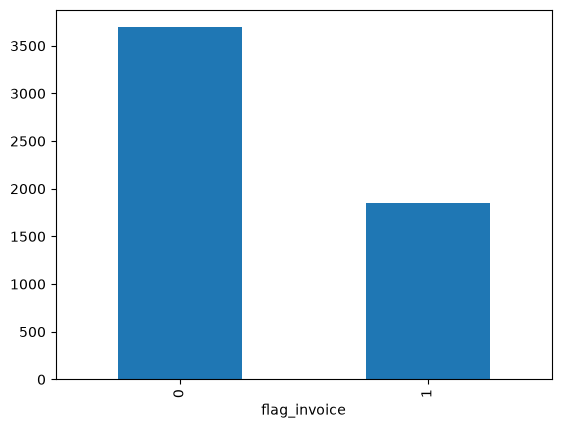

In [14]:
df["flag_invoice"].value_counts().plot(kind="bar")

In [15]:
flaged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [16]:
flaged.info()

<class 'pandas.DataFrame'>
Index: 1850 entries, 0 to 5542
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             1850 non-null   int64  
 1   Invoice_Quantity     1850 non-null   int64  
 2   Invoice_Dollars      1850 non-null   float64
 3   Freight              1850 non-null   float64
 4   Days_PO_To_Invoice   1850 non-null   float64
 5   Days_To_Pay          1850 non-null   float64
 6   Total_Brands         1850 non-null   int64  
 7   Total_Item_Quantity  1850 non-null   int64  
 8   Total_Item_Dollars   1850 non-null   float64
 9   Avg_Receiving_Delay  1850 non-null   float64
 10  flag_invoice         1850 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 173.4 KB


In [17]:
normal.info()

<class 'pandas.DataFrame'>
Index: 3693 entries, 2 to 5404
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             3693 non-null   int64  
 1   Invoice_Quantity     3693 non-null   int64  
 2   Invoice_Dollars      3693 non-null   float64
 3   Freight              3693 non-null   float64
 4   Days_PO_To_Invoice   3693 non-null   float64
 5   Days_To_Pay          3693 non-null   float64
 6   Total_Brands         3693 non-null   int64  
 7   Total_Item_Quantity  3693 non-null   int64  
 8   Total_Item_Dollars   3693 non-null   float64
 9   Avg_Receiving_Delay  3693 non-null   float64
 10  flag_invoice         3693 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 346.2 KB


In [18]:
df.columns

Index(['PONumber', 'Invoice_Quantity', 'Invoice_Dollars', 'Freight',
       'Days_PO_To_Invoice', 'Days_To_Pay', 'Total_Brands',
       'Total_Item_Quantity', 'Total_Item_Dollars', 'Avg_Receiving_Delay',
       'flag_invoice'],
      dtype='str')

In [19]:
metrics=['Invoice_Quantity', 'Invoice_Dollars', 'Freight',
       'Days_PO_To_Invoice', 'Days_To_Pay', 'Total_Brands',
       'Total_Item_Quantity', 'Total_Item_Dollars', 'Avg_Receiving_Delay']

In [20]:
significant_features=[]
non_significant_features=[]
results=[]

In [21]:
from scipy.stats import ttest_ind
for metric in metrics:
    flaged_mean=flaged[metric].mean()
    normal_mean=normal[metric].mean()
    t_stat, p_value = ttest_ind(
    flaged[metric].dropna(),
    normal[metric].dropna(),
    equal_var=False)
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
    "metric": metric,
    "flagged_mean": flaged_mean.round(2),
    "normal_mean": normal_mean.round(2),
    "p_value": p_value.round(3)
})
    else:
        non_significant_features.append(metric)
    

In [22]:
significant_features

['Invoice_Quantity',
 'Invoice_Dollars',
 'Freight',
 'Days_PO_To_Invoice',
 'Total_Item_Quantity',
 'Total_Item_Dollars',
 'Avg_Receiving_Delay']

In [23]:
non_significant_features

['Days_To_Pay', 'Total_Brands']

In [24]:
results

[{'metric': 'Invoice_Quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'Invoice_Dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'Days_PO_To_Invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'Total_Item_Quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'Total_Item_Dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Avg_Receiving_Delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [25]:
X=df[['Invoice_Quantity', 'Invoice_Dollars', 'Freight', 'Days_PO_To_Invoice', 'Total_Item_Quantity', 'Total_Item_Dollars']]
Y=df['flag_invoice']

In [26]:
X.describe().round(3)

,Invoice_Quantity,Invoice_Dollars,Freight,Days_PO_To_Invoice,Total_Item_Quantity,Total_Item_Dollars
count,5543.000,5543.000,5543.000,5543.000,5543.000,5543.000
mean,6058.881,58073.384,295.954,16.424,6058.881,58073.384
std,14453.338,140234.031,713.585,3.127,14453.338,140234.031
min,1.000,4.140,0.020,9.000,1.000,4.140
25%,83.000,967.810,5.020,14.000,83.000,967.810
50%,423.000,4765.450,24.730,16.000,423.000,4765.450
75%,5100.500,44587.175,229.660,19.000,5100.500,44587.175
max,141660.000,1660435.880,8468.220,23.000,141660.000,1660435.880


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
from xgboost import XGBClassifier

In [30]:
model1=LogisticRegression()
model2=DecisionTreeClassifier(random_state=42)
model3=RandomForestClassifier(random_state=42)
model4=svm.SVC()

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)
xgb_search = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)

In [31]:
model1.fit(x_train,y_train)
model2.fit(x_train,y_train)
model3.fit(x_train,y_train)
model4.fit(x_train,y_train)
xgb_search.fit(x_train, y_train)
model5 = xgb_search.best_estimator_
print('Best XGBoost params:', xgb_search.best_params_)
print('Best CV F1 score:', round(xgb_search.best_score_, 4))

Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1 score: 0.805


In [32]:
pred1=model1.predict(x_test)
pred2=model2.predict(x_test)
pred3=model3.predict(x_test)
pred4=model4.predict(x_test)
pred5=model5.predict(x_test)

In [33]:
result=pd.DataFrame([['Logistic Regression',accuracy_score(y_test,pred1),precision_score(y_test,pred1),recall_score(y_test,pred1),f1_score(y_test,pred1)],
                    ['Decision Tree Classifier',accuracy_score(y_test,pred2),precision_score(y_test,pred2),recall_score(y_test,pred2),f1_score(y_test,pred2)],
                    ['Random Forest Classifier',accuracy_score(y_test,pred3),precision_score(y_test,pred3),recall_score(y_test,pred3),f1_score(y_test,pred3)],
                     ['SVM',accuracy_score(y_test,pred4),precision_score(y_test,pred4),recall_score(y_test,pred4),f1_score(y_test,pred4)],
                     ['XG_boost',accuracy_score(y_test,pred5),precision_score(y_test,pred5),recall_score(y_test,pred5),f1_score(y_test,pred5)]
                    ],columns=['Model','Accuracy','Precision','Recall','F1 Score'])
                     

In [34]:
result

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.660054,0.594595,0.057292,0.104513
1,Decision Tree Classifier,0.822362,0.752022,0.726562,0.739073
2,Random Forest Classifier,0.879170,0.937063,0.697917,0.800000
3,SVM,0.738503,0.919643,0.268229,0.415323
4,XG_boost,0.880974,0.937500,0.703125,0.803571


In [43]:
print(classification_report(y_test,pred5))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91       725
           1       0.94      0.70      0.80       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [41]:
confusion_matrix(y_test,pred5)

array([[707,  18],
       [114, 270]])

In [35]:
X.columns

Index(['Invoice_Quantity', 'Invoice_Dollars', 'Freight', 'Days_PO_To_Invoice',
       'Total_Item_Quantity', 'Total_Item_Dollars'],
      dtype='str')